In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load dataset
print("Loading credit card fraud dataset...")
df = pd.read_csv('../dataset/creditcard.csv')  # Fixed path

print("\n" + "="*70)
print("BASIC DATASET INFO".center(70))
print("="*70)

# Dataset shape
print(f"\nDataset shape: {df.shape}")
print(f"   • Transactions: {len(df):,}")
print(f"   • Features: {len(df.columns)}")

# Column info
print(f"\nColumns:")
print(f"   • Time, Amount, V1-V28 (PCA features), Class (target)")

# First rows
print("\n" + "-"*70)
print("First 5 rows:")
print("-"*70)
display(df.head())

# Data types
print("\n" + "-"*70)
print("Data types summary:")
print("-"*70)
print(df.dtypes.value_counts())

Loading credit card fraud dataset...

                          BASIC DATASET INFO                          

Dataset shape: (284807, 31)
   • Transactions: 284,807
   • Features: 31

Columns:
   • Time, Amount, V1-V28 (PCA features), Class (target)

----------------------------------------------------------------------
First 5 rows:
----------------------------------------------------------------------


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



----------------------------------------------------------------------
Data types summary:
----------------------------------------------------------------------
float64    30
int64       1
Name: count, dtype: int64


In [4]:
print("="*70)
print("FRAUD STATISTICS & DATA QUALITY".center(70))
print("="*70)

# Class distribution
fraud_count = df['Class'].sum()
normal_count = len(df) - fraud_count
fraud_percentage = (fraud_count / len(df)) * 100

print(f"\nCLASS DISTRIBUTION:")
print(f"   • Normal transactions: {normal_count:,} ({100-fraud_percentage:.3f}%)")
print(f"   • Fraudulent transactions: {fraud_count:,} ({fraud_percentage:.3f}%)")
print(f"   • Imbalance ratio: {normal_count/fraud_count:.1f}:1")
print(f"   • (For every 1 fraud, there are ~{normal_count/fraud_count:.0f} normal transactions)")

# Data quality
print(f"\nDATA QUALITY:")
print(f"   • Missing values: {df.isnull().sum().sum()}")
print(f"   • Duplicate rows: {df.duplicated().sum()}")

# Feature statistics
print(f"\nTRANSACTION AMOUNTS:")
print(f"   • Overall range: ${df['Amount'].min():.2f} - ${df['Amount'].max():.2f}")
print(f"   • Normal median: ${df[df['Class']==0]['Amount'].median():.2f}")
print(f"   • Fraud median: ${df[df['Class']==1]['Amount'].median():.2f}")

print(f"\nTIME RANGE:")
print(f"   • Duration: {df['Time'].max()/3600:.1f} hours")
print(f"   • Time range: {df['Time'].min():.0f}s to {df['Time'].max():.0f}s")

# V features
v_features = [col for col in df.columns if col.startswith('V')]
print(f"\nANONYMIZED FEATURES:")
print(f"   • {len(v_features)} PCA-transformed features (V1-V28)")

                   FRAUD STATISTICS & DATA QUALITY                    

CLASS DISTRIBUTION:
   • Normal transactions: 284,315 (99.827%)
   • Fraudulent transactions: 492 (0.173%)
   • Imbalance ratio: 577.9:1
   • (For every 1 fraud, there are ~578 normal transactions)

DATA QUALITY:
   • Missing values: 0
   • Duplicate rows: 1081

TRANSACTION AMOUNTS:
   • Overall range: $0.00 - $25691.16
   • Normal median: $22.00
   • Fraud median: $9.25

TIME RANGE:
   • Duration: 48.0 hours
   • Time range: 0s to 172792s

ANONYMIZED FEATURES:
   • 28 PCA-transformed features (V1-V28)


In [5]:
print("="*70)
print("STATISTICAL SUMMARIES".center(70))
print("="*70)

# Amount statistics by class
print("\nAMOUNT STATISTICS BY CLASS:")
print("-"*70)
display(df.groupby('Class')['Amount'].describe())

# Sample transactions
print("\n" + "="*70)
print("SAMPLE TRANSACTIONS".center(70))
print("="*70)

print("\nSample Normal Transaction:")
print("-"*70)
display(df[df['Class'] == 0].iloc[0:1].T)

print("\nSample Fraudulent Transaction:")
print("-"*70)
display(df[df['Class'] == 1].iloc[0:1].T)

                        STATISTICAL SUMMARIES                         

AMOUNT STATISTICS BY CLASS:
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87



                         SAMPLE TRANSACTIONS                          

Sample Normal Transaction:
----------------------------------------------------------------------


,0
Time,0.000000
V1,-1.359807
V2,-0.072781
V3,2.536347
V4,1.378155
V5,-0.338321
V6,0.462388
V7,0.239599
V8,0.098698
V9,0.363787



Sample Fraudulent Transaction:
----------------------------------------------------------------------


,541
Time,406.000000
V1,-2.312227
V2,1.951992
V3,-1.609851
V4,3.997906
V5,-0.522188
V6,-1.426545
V7,-2.537387
V8,1.391657
V9,-2.770089


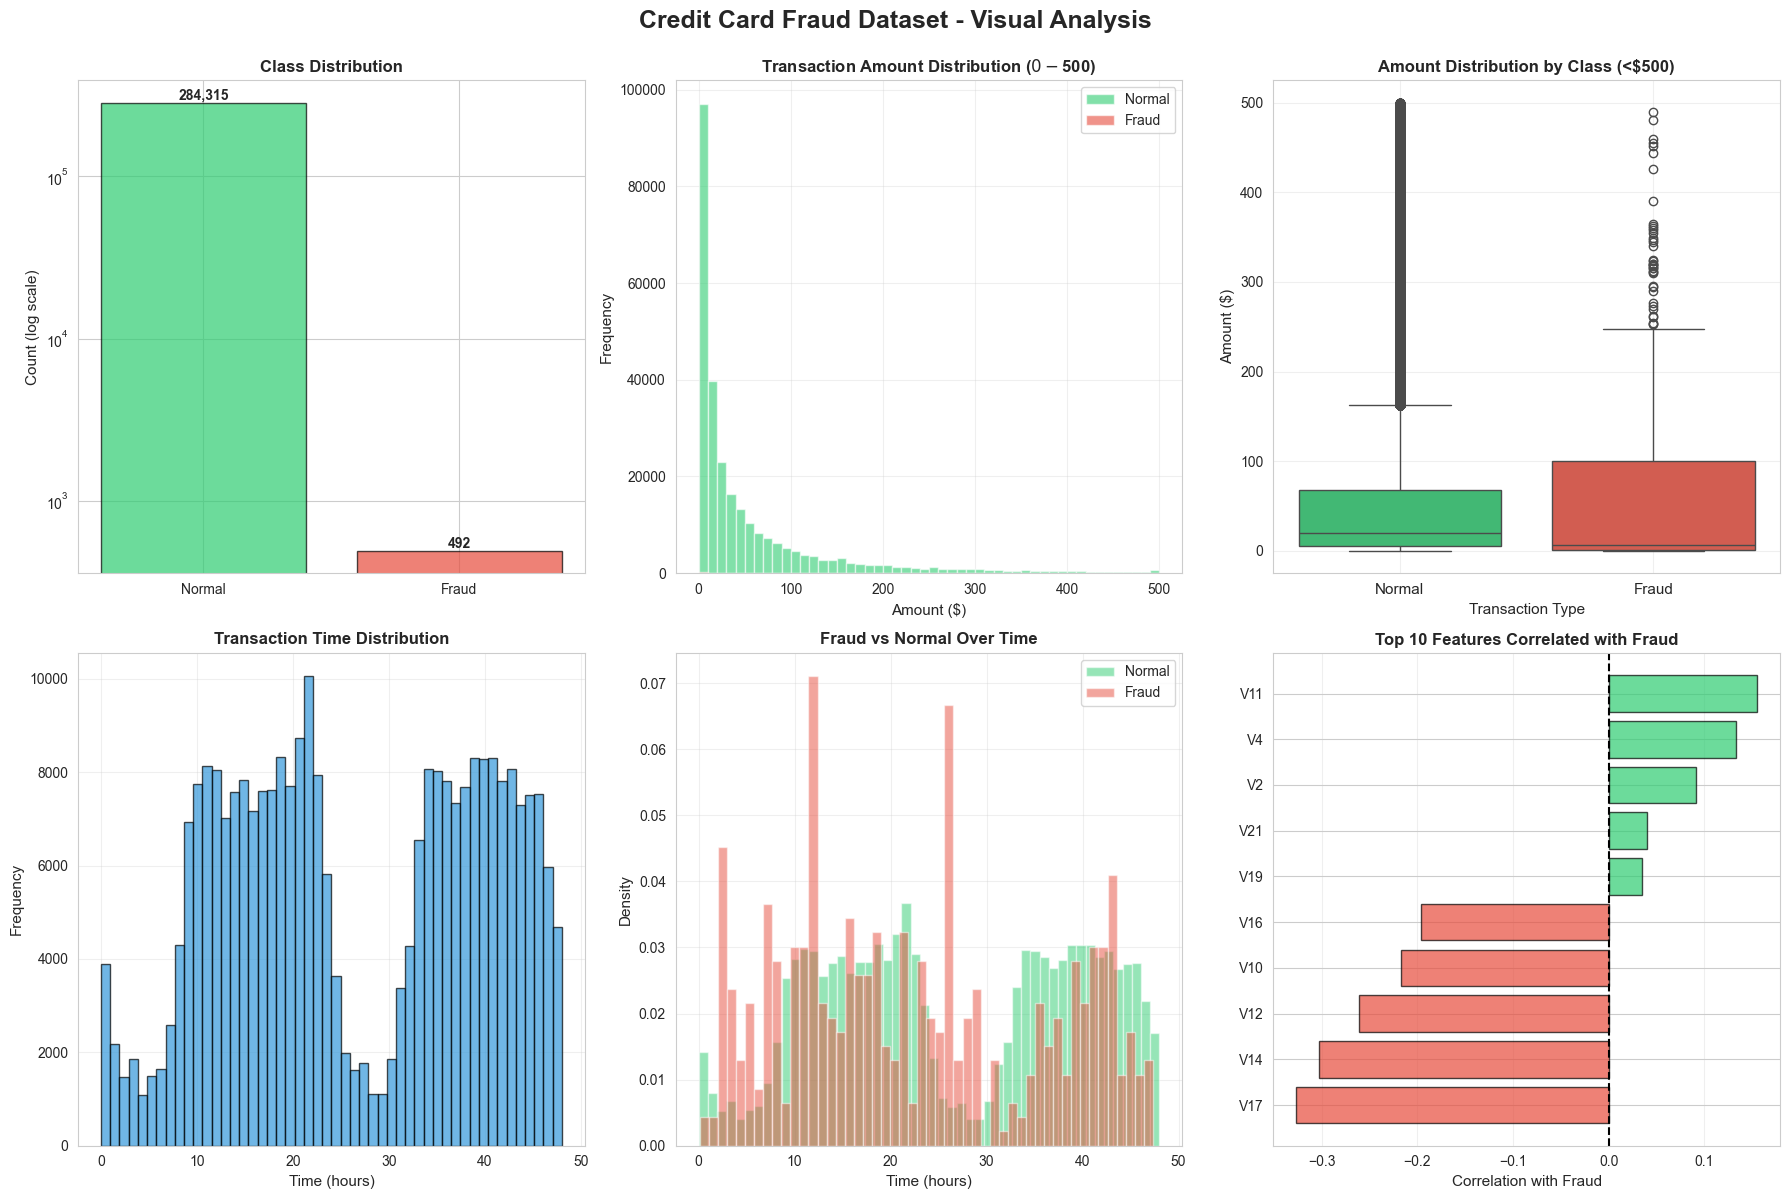

All visualizations generated successfully!


In [6]:
# Create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Credit Card Fraud Dataset - Visual Analysis', fontsize=18, fontweight='bold', y=0.995)

# Plot 1: Class Distribution (Log scale)
ax1 = axes[0, 0]
class_counts = df['Class'].value_counts()
colors = ["#2ecc71", '#e74c3c']
bars = ax1.bar(['Normal', 'Fraud'], class_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Count (log scale)', fontsize=11)
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
for i, (bar, v) in enumerate(zip(bars, class_counts.values)):
    ax1.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Amount Distribution (0-500 range)
ax2 = axes[0, 1]
normal_amounts = df[df['Class'] == 0]['Amount']
fraud_amounts = df[df['Class'] == 1]['Amount']
ax2.hist(normal_amounts, bins=50, alpha=0.6, label='Normal', color='#2ecc71', range=(0, 500))
ax2.hist(fraud_amounts, bins=50, alpha=0.6, label='Fraud', color='#e74c3c', range=(0, 500))
ax2.set_xlabel('Amount ($)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Transaction Amount Distribution ($0-$500)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Plot 3: Amount Boxplot by Class
ax3 = axes[0, 2]
df_plot = df[df['Amount'] < 500]
sns.boxplot(data=df_plot, x='Class', y='Amount', ax=ax3, palette=['#2ecc71', '#e74c3c'])
ax3.set_xticklabels(['Normal', 'Fraud'], fontsize=11)
ax3.set_title('Amount Distribution by Class (<$500)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Amount ($)', fontsize=11)
ax3.set_xlabel('Transaction Type', fontsize=11)
ax3.grid(alpha=0.3)

# Plot 4: Time Distribution
ax4 = axes[1, 0]
ax4.hist(df['Time']/3600, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Time (hours)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Transaction Time Distribution', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

# Plot 5: Fraud Distribution Over Time
ax5 = axes[1, 1]
time_bins = np.linspace(df['Time'].min(), df['Time'].max(), 50)
fraud_time = df[df['Class'] == 1]['Time']
normal_time = df[df['Class'] == 0]['Time']
ax5.hist(normal_time/3600, bins=50, alpha=0.5, label='Normal', color='#2ecc71', density=True)
ax5.hist(fraud_time/3600, bins=50, alpha=0.5, label='Fraud', color='#e74c3c', density=True)
ax5.set_xlabel('Time (hours)', fontsize=11)
ax5.set_ylabel('Density', fontsize=11)
ax5.set_title('Fraud vs Normal Over Time', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(alpha=0.3)

# Plot 6: Feature Correlation with Fraud
ax6 = axes[1, 2]
v_features = [col for col in df.columns if col.startswith('V')]
correlations = df[v_features + ['Class']].corr()['Class'].drop('Class').sort_values()
top_pos = correlations.tail(5)
top_neg = correlations.head(5)
top_features = pd.concat([top_neg, top_pos])
colors_corr = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_features.values]
bars = ax6.barh(range(len(top_features)), top_features.values, color=colors_corr, alpha=0.7, edgecolor='black')
ax6.set_yticks(range(len(top_features)))
ax6.set_yticklabels(top_features.index, fontsize=10)
ax6.set_xlabel('Correlation with Fraud', fontsize=11)
ax6.set_title('Top 10 Features Correlated with Fraud', fontsize=12, fontweight='bold')
ax6.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax6.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("All visualizations generated successfully!")

In [8]:
print("="*70)
print("KEY INSIGHTS & NEXT STEPS".center(70))
print("="*70)

# Calculate correlations for insights
v_features = [col for col in df.columns if col.startswith('V')]
correlations = df[v_features + ['Class']].corr()['Class'].drop('Class').sort_values()

print("\n1. CLASS IMBALANCE:")
fraud_pct = (df['Class'].sum() / len(df)) * 100
print(f"   • Only {fraud_pct:.3f}% are fraudulent - imbalanced.")
print(f"   • Solution: Use XGBoost's scale_pos_weight parameter")

print("\n2. TRANSACTION AMOUNTS:")
print(f"   • Normal median: ${df[df['Class']==0]['Amount'].median():.2f}")
print(f"   • Fraud median: ${df[df['Class']==1]['Amount'].median():.2f}")
print(f"   • Insight: Fraudulent transactions tend to be smaller amounts")

print("\n3. TEMPORAL PATTERNS:")
print(f"   • Dataset spans {df['Time'].max()/3600:.1f} hours (~2 days)")
print(f"   • Fraud occurs throughout the time period (no specific time bias)")

print("\n4. MOST IMPORTANT FEATURES (by correlation):")
print(f"   • Positively correlated with fraud:")
for feat in correlations.tail(3).index:
    print(f"     → {feat}: {correlations[feat]:+.3f}")
print(f"   • Negatively correlated with fraud:")
for feat in correlations.head(3).index:
    print(f"     → {feat}: {correlations[feat]:+.3f}")

print("\n" + "="*70)
print("READY FOR MODELING".center(70))
print("="*70)
print("\nDataset is clean (no missing values, no duplicates)")
print("Features are numeric and ready for ML")
print("Target variable is binary (0=Normal, 1=Fraud)")
print("Will use XGBoost with special handling for class imbalance")
print("Key metrics: Precision, Recall, F1-Score, AUC-ROC")


                      KEY INSIGHTS & NEXT STEPS                       

1. CLASS IMBALANCE:
   • Only 0.173% are fraudulent - imbalanced.
   • Solution: Use XGBoost's scale_pos_weight parameter

2. TRANSACTION AMOUNTS:
   • Normal median: $22.00
   • Fraud median: $9.25
   • Insight: Fraudulent transactions tend to be smaller amounts

3. TEMPORAL PATTERNS:
   • Dataset spans 48.0 hours (~2 days)
   • Fraud occurs throughout the time period (no specific time bias)

4. MOST IMPORTANT FEATURES (by correlation):
   • Positively correlated with fraud:
     → V2: +0.091
     → V4: +0.133
     → V11: +0.155
   • Negatively correlated with fraud:
     → V17: -0.326
     → V14: -0.303
     → V12: -0.261

                          READY FOR MODELING                          

Dataset is clean (no missing values, no duplicates)
Features are numeric and ready for ML
Target variable is binary (0=Normal, 1=Fraud)
Will use XGBoost with special handling for class imbalance
Key metrics: Precision, Reca


### Fraud Detection Summary:
- If the model just predicts "NOT FRAUD" for EVERYTHING, it's 99.83% accurate!
- Accuracy is a **terrible metric** for this problem
- Need to focus on Precision/Recall/F1 instead
- You need a system that catches threats (Recall) without too many false alarms (Precision)
- A few huge transactions ($25,691 max) pull the mean up
- V11: +0.155 (positive correlation with fraud)
- V17: -0.326 (negative correlation with fraud)

### Class Imbalance:
- MUST use `scale_pos_weight` in XGBoost (577.9)
- MUST evaluate on Precision/Recall/F1, NOT accuracy
- Consider SMOTE or undersampling (but scale_pos_weight is better)

### Values:
  - Normal median: $22.00
  - Fraud median: $9.25
  - Normal mean: $88.29
  - Fraud mean: $122.21

### Transaction Amount Insights:
- Smaller transactions avoid detection thresholds
- Flying "under the radar" strategy
- But some frauds are MASSIVE
- The max fraud is $2,125 (vs $25,691 normal max)

### Time Feature Insights:
- Two clear peaks around hours 10-20 and 35-45
- Likely represents **two business days**
- Fraudsters operate 24/7 (no clear time preference)
- `Time` feature alone won't be a strong predictor
- Could create derived features: `hour_of_day`, `is_night_time`
- The 48-hour window suggests this is a **continuous monitoring scenario**


- **Top 5 Fraud INDICATORS (positive correlation):**
  - V11: +0.155 (strongest fraud signal)
  - V4: +0.133
  - V2: +0.091
  - V21: (small positive)
  - V19: (small positive)

- **Top 5 Fraud PROTECTORS (negative correlation):**
  - V17: -0.326 (STRONGEST predictor overall!)
  - V14: -0.303
  - V12: -0.261
  - V10: (medium negative)
  - V16: (medium negative)

- **A. V17 is your MVP:**
  - Strongest correlation (-0.326)
  - When V17 is high → Very likely normal
  - When V17 is low → More suspicious
  - XGBoost will heavily weight this feature
